# DEAP

In [1]:
import deap

In [2]:
import random

from deap import base
from deap import creator
from deap import tools

In [3]:
import numpy as np
import os
import polars as pl

## Load admissions data

In [4]:
path_to_msoa_stats = os.path.join('..', 'data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [5]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [6]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [7]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [8]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [9]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [10]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [11]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [12]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [13]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [14]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [15]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [16]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [17]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [18]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Admissions prediction setup

In [19]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [20]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [21]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

The following function combines the previous ones to do the main calculations we need:

In [22]:
def main_admissions(coeffs, args):
    x_lists = args[0]
    admissions = args[1]
    yhat = predict_admissions(x_lists, coeffs)
    # Use only one of the following options for checking the fit:
    # sum_sqres = find_square_residuals(yhat, admissions)
    sum_sqres = find_mean_abs_diff(yhat, admissions)
    return sum_sqres

To check accuracy, the following function calculates R-squared:

In [23]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Parameter setup

Which values are allowed for each coefficient?

In [24]:
# From minimiser before:
best_coeffs_by_depriv = {
    '0.0': [0.0006, 0.003, 0.004, 0.005, 0.017],
    '0.2': [0.0005, 0.002, 0.003, 0.004, 0.017],
    '0.4': [0.0004, 0.001, 0.002, 0.004, 0.017],
    '0.6': [0.0004, 0.001, 0.002, 0.004, 0.015],
    '0.8': [0.0003, 0.001, 0.002, 0.003, 0.015],
}

In [25]:
start_ranges_by_coeff = [
    [0.0001, 0.0007],
    [0.0007, 0.009],
    [0.0006, 0.006],
    [0.0007, 0.009],
    [0.012, 0.019]
]

In [26]:
def gen_attr(start_ranges_by_coeff, best_coeffs):
    new_coeffs = []
    for i, s in enumerate(start_ranges_by_coeff):
        offset = random.gauss(np.mean(s), 0.5*np.std(s)) - np.mean(s)
        new_coeffs.append(best_coeffs[i] + offset)

    new_coeffs = clip_coeffs(start_ranges_by_coeff, new_coeffs)
    new_coeffs = round_coeffs(new_coeffs)
    new_coeffs = force_coeffs_increasing(new_coeffs)
    return tuple(new_coeffs)

In [27]:
# def gen_attr(start_ranges_by_coeff):
#     return tuple([round(random.uniform(s[0], s[1]), 7) for s in start_ranges_by_coeff])

In [28]:
def clip_coeffs(start_ranges_by_coeff, coeffs):
    # Clip coefficients to sit within allowed range.
    clipped_coeffs = []
    for i, coeff in enumerate(coeffs):
        c = np.clip(coeff, a_min=start_ranges_by_coeff[i][0], a_max=start_ranges_by_coeff[i][1],)
        clipped_coeffs.append(c)
    return clipped_coeffs

In [29]:
def round_coeffs(coeffs):
    return tuple([round(c, 5) for c in coeffs])

In [50]:
def force_coeffs_increasing(coeffs):
    # Make sure each coefficient is no larger than the next.
    # Manual overwrite based on current parameter ranges.
    new_coeffs = [c for c in coeffs]
    if new_coeffs[2] < 0.0007:
        new_coeffs[1] = 0.0007
        new_coeffs[2] = 0.0007
    elif new_coeffs[2] < new_coeffs[1]:
        new_coeffs[1] = new_coeffs[2]
    if new_coeffs[3] < new_coeffs[2]:
        new_coeffs[3] = new_coeffs[2]
    return new_coeffs  # [c if (c <= coeffs[i+1]) else coeffs[i+1] for i, c in enumerate(coeffs[:-1])] + [coeffs[-1]]

In [51]:
force_coeffs_increasing([0.00049, 0.00403, 0.00094, 0.00094, 0.01711])

[0.00049, 0.00094, 0.00094, 0.00094, 0.01711]

Example generate some coeffs:

In [31]:
gen_attr(start_ranges_by_coeff, best_coeffs_by_depriv['0.0'])

(0.00055, 0.00267, 0.00267, 0.00674, 0.019)

## Set up algorithm


In [32]:
creator.create("FitnessMax", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [33]:
toolbox = base.Toolbox()

# Attribute generator 
#                      define 'attr_bool' to be an attribute ('gene')
#                      which corresponds to integers sampled uniformly
#                      from the range [0,1] (i.e. 0 or 1 with equal
#                      probability)
# toolbox.register("attr_unif", random.uniform, 0, 1)

# Structure initializers
#                         define 'individual' to be an individual
#                         consisting of 100 'attr_bool' elements ('genes')
# toolbox.register("individual", tools.initIterate, creator.Individual, gen_attr, start_ranges_by_coeff)


In [34]:
# the goal ('fitness') function to be maximized
def eval_admissions(admissions, x_lists, individual):
    
    yhat = predict_admissions(x_lists, individual)
    # Use only one of the following options for checking the fit:
    # sum_sqres = find_square_residuals(yhat, admissions)
    sum_sqres = find_mean_abs_diff(yhat, admissions)
    return sum_sqres,

In [35]:
for s in start_ranges_by_coeff:
    m = np.mean(s)
    s = np.std(s)
    print(m, s)
    for i in range(10):
        print('    ', random.gauss(m, s))

0.0004 0.0003
     4.051702491899461e-05
     0.00020467755163543804
     0.0002512262557330503
     0.00020190695995509023
     -3.0168731292421543e-05
     0.00026093130502175774
     0.00027459138045635633
     0.0007152906756582858
     0.0011083158807250098
     0.0007217560645120657
0.004849999999999999 0.004149999999999999
     0.009229521061855058
     0.005027731490402853
     0.0010990920090300509
     0.000572937298140324
     -0.001874599392009818
     0.00410040457296997
     0.005347082867606129
     0.0033736286034424332
     0.006173196985411432
     0.009921399471601183
0.0033 0.0027
     0.0035394655321403577
     0.0020523083796714315
     0.002636622259832678
     0.008966877589050844
     0.0018290503030533728
     0.004524786253030289
     0.002879557029776873
     0.005201081146942235
     0.006067547777591363
     0.0071864618309540745
0.004849999999999999 0.004149999999999999
     0.0030752696592083384
     0.007386373349693892
     0.006186637528219287
     0.

In [36]:
def mutate_coeffs(start_ranges_by_coeff, individual, indpb=0.05):
    mutated = []
    for i, s in enumerate(start_ranges_by_coeff):
        if random.random() < indpb:
            # Mutate
            current_val = individual[i]
            offset = random.gauss(np.mean(s), np.std(s)) - np.mean(s)
            mutated.append(current_val + offset)
        else:
            # Keep current value
            mutated.append(individual[i])
    return mutated

In [37]:
for i in range(10):
    g = gen_attr(start_ranges_by_coeff, best_coeffs_by_depriv['0.0'])
    m = mutate_coeffs(start_ranges_by_coeff, g, indpb=0.20)
    print(g)
    print(m)
    print('')

(0.00052, 0.0007, 0.00316, 0.00349, 0.01607)
[0.00052, 0.0007, 0.00316, 0.00349, 0.01607]

(0.00069, 0.00082, 0.006, 0.00632, 0.01834)
[0.00069, 0.00082, 0.006, 0.00632, 0.01834]

(0.00058, 0.00244, 0.00244, 0.00251, 0.01776)
[0.00058, 0.00244, 0.00244, 0.00251, 0.01315690842154707]

(0.0005, 0.00323, 0.00323, 0.00691, 0.01763)
[0.0005, 0.008514272587279444, 0.00323, 0.01139380273547019, 0.01763]

(0.00066, 0.00261, 0.0007, 0.0007, 0.0176)
[0.00066, 0.00261, -0.00113502415826853, 0.0007, 0.0176]

(0.0007, 0.00161, 0.0057, 0.00678, 0.019)
[0.0007, 0.00161, 0.0057, 0.00678, 0.019]

(0.0007, 0.0034, 0.00555, 0.00555, 0.01853)
[0.0007, 0.0034, 0.0033261437045790623, 0.00555, 0.01853]

(0.0007, 0.00158, 0.00483, 0.00483, 0.01637)
[0.0007, 0.00158, 0.00483, 0.00483, 0.01637]

(0.0007, 0.00241, 0.00229, 0.00229, 0.019)
[0.0007917136541687833, 0.00241, 0.00229, 0.00229, 0.019]

(0.0007, 0.00355, 0.00432, 0.00722, 0.01888)
[0.0007, 0.00355, 0.00432, 0.00722, 0.01888]



In [53]:
#----------
# Operator registration
#----------

# register the crossover operator
# toolbox.register("mate", tools.cxUniform, indpb=0.4)
toolbox.register("mate", tools.cxTwoPoint)

# register a mutation operator with a probability to
# flip each attribute/gene of 0.05
# toolbox.register("mutate", tools.mutGaussian, mu=1e-4, sigma=1e-3, indpb=0.05)
toolbox.register('mutate', mutate_coeffs, start_ranges_by_coeff, indpb=0.20)

# operator for selecting individuals for breeding the next
# generation: each individual of the current generation
# is replaced by the 'fittest' (best) of three individuals
# drawn randomly from the current generation.
toolbox.register("select", tools.selTournament, tournsize=3)

#----------

toolbox.register("clip", clip_coeffs, start_ranges_by_coeff)
toolbox.register("round", round_coeffs)
toolbox.register("force_increasing", force_coeffs_increasing)

## Run

Run for each IMD band separately.

In [54]:
def main(seed):
    random.seed(seed)

    # create an initial population of 300 individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=500)

    # CXPB  is the probability with which two individuals
    #       are crossed
    #
    # MUTPB is the probability for mutating an individual
    CXPB = 0.8
    MUTPB = 0.2

    print("Start of evolution")

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    print(f"  Evaluated {len(pop)} individuals")

    # Extracting all the fitnesses of 
    fits = [ind.fitness.values[0] for ind in pop]

    # Variable keeping track of the number of generations
    g = 0

    # Begin the evolution
    while g < 20:
        # A new generation
        g = g + 1
        print(f'-- Generation {g} --')

        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):

            # cross two individuals with probability CXPB
            if random.random() < CXPB:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:

            # mutate an individual with probability MUTPB
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        
        # Clip values to fit within parameter bounds.
        for ind in invalid_ind:
            ind[:] = toolbox.clip(ind)
        # Round values.
        for ind in invalid_ind:
            ind[:] = toolbox.round(ind)
        # Force coefficients to increase with age band.
        for ind in invalid_ind:
            ind[:] = toolbox.force_increasing(ind)
        
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        print(f"  Evaluated {len(invalid_ind)} individuals")

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        # Gather all the fitnesses in one list and print the stats
        fits = [ind.fitness.values[0] for ind in pop]

        length = len(pop)
        mean = sum(fits) / length
        sum2 = sum(x*x for x in fits)
        std = abs(sum2 / length - mean**2)**0.5

        print(f'  Min {min(fits):9.5f}')
        print(f'  Max {max(fits):9.5f}')
        print(f'  Avg {mean:9.5f}')
        print(f'  Std {std:9.5f}')

    print("-- End of (successful) evolution --")

    best_ind = tools.selBest(pop, 1)[0]
    best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
    b = best_ind.fitness.values[0]
    print(f'Best individual is ({best_ind_str}), {b:.5f}')

    return pop

In [63]:
qmin = 0.0

best_coeffs = best_coeffs_by_depriv[str(qmin)]

toolbox.register("gen_attr", gen_attr, start_ranges_by_coeff, best_coeffs)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.gen_attr)

# define the population to be a list of individuals
# but don't specify how many here.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
# MSOA data in the same order as those coefficients:
x_lists = [df_stats_here[a] for a in age_numbers]
admissions = df_stats_here['admissions']

# For this deprivation quantile, need to pass these admissions
# into the evaluation function:
# register the goal / fitness function
toolbox.register("evaluate", eval_admissions, admissions, x_lists)

pop_results = main(seed=424242)

Start of evolution
  Evaluated 500 individuals
-- Generation 1 --
  Evaluated 416 individuals
  Min   2.38669
  Max   3.45812
  Avg   2.47046
  Std   0.11259
-- Generation 2 --
  Evaluated 426 individuals
  Min   2.38780
  Max   3.16297
  Avg   2.43685
  Std   0.06960
-- Generation 3 --
  Evaluated 418 individuals
  Min   2.38552
  Max   2.74238
  Avg   2.42381
  Std   0.04840
-- Generation 4 --
  Evaluated 415 individuals
  Min   2.38624
  Max   2.71375
  Avg   2.41713
  Std   0.04187
-- Generation 5 --
  Evaluated 404 individuals
  Min   2.38541
  Max   2.62820
  Avg   2.40713
  Std   0.02822
-- Generation 6 --
  Evaluated 411 individuals
  Min   2.38514
  Max   2.55831
  Avg   2.40339
  Std   0.02391
-- Generation 7 --
  Evaluated 398 individuals
  Min   2.38505
  Max   2.58436
  Avg   2.40176
  Std   0.02275
-- Generation 8 --
  Evaluated 398 individuals
  Min   2.38503
  Max   2.49896
  Avg   2.39695
  Std   0.01447
-- Generation 9 --
  Evaluated 428 individuals
  Min   2.38503
  

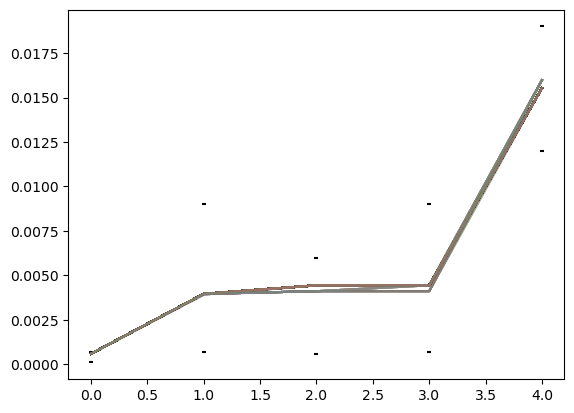

In [64]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for i, s in enumerate(start_ranges_by_coeff):
    for l in s:
        ax.scatter(i, l, color='k', marker='_', s=10)
    

for individual in pop_results:
    ax.plot(individual, alpha=0.1)
    # print(g)
plt.show()

In [61]:
best_coeffs

[0.0006, 0.003, 0.004, 0.005, 0.017]

In [65]:

for individual in pop_results:
    print(individual)

[0.00059, 0.00396, 0.00411, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01598]
[0.00059, 0.00396, 0.00411, 0.00411, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01598]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01598]
[0.00059, 0.00396, 0.00411, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00392, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00411, 0.00411, 0.01598]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.00444, 0.01553]
[0.00059, 0.00396, 0.00444, 0.0044

In [62]:

for individual in pop_results:
    print(individual)

[0.00057, 0.00411, 0.00462, 0.00462, 0.01558]
[0.00057, 0.00411, 0.00427, 0.00451, 0.0158]
[0.00057, 0.00411, 0.00451, 0.00452, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00452, 0.01558]
[0.00057, 0.00411, 0.00427, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00451, 0.0158]
[0.00057, 0.00411, 0.00427, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00452, 0.0158]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00462, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00452, 0.01558]
[0.00057, 0.00411, 0.00427, 0.00451, 0.0158]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00427, 0.00451, 0.0158]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00461, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00452, 0.01558]
[0.00057, 0.00411, 0.00462, 0.00462, 0.01543]
[0.00057, 0.00411, 0.00451, 0.00451, 0.01558]
[0.00057, 0.00411, 0.00451, 0.00461, 0.

In [58]:

for individual in pop_results:
    print(individual)

[0.00058, 0.00437, 0.00439, 0.00444, 0.0153]
[0.00058, 0.00437, 0.00444, 0.00444, 0.01538]
[0.00056, 0.00437, 0.00444, 0.00478, 0.01503]
[0.00057, 0.00437, 0.00478, 0.00478, 0.01564]
[0.00056, 0.00437, 0.00437, 0.00444, 0.01564]
[0.00056, 0.00437, 0.00487, 0.00487, 0.01503]
[0.00058, 0.00437, 0.00437, 0.00444, 0.01538]
[0.00058, 0.00437, 0.00444, 0.00444, 0.01538]
[0.00056, 0.00437, 0.00437, 0.00444, 0.01564]
[0.00056, 0.00437, 0.00437, 0.00444, 0.01564]
[0.00056, 0.00437, 0.00437, 0.00444, 0.01503]
[0.00057, 0.00437, 0.00437, 0.00478, 0.01564]
[0.00058, 0.00437, 0.00444, 0.00444, 0.0151]
[0.00056, 0.00437, 0.00483, 0.00483, 0.0151]
[0.00057, 0.00437, 0.00437, 0.00444, 0.01536]
[0.00057, 0.00437, 0.00439, 0.00444, 0.01536]
[0.00057, 0.00437, 0.00437, 0.00478, 0.01536]
[0.00056, 0.00437, 0.00478, 0.00478, 0.01503]
[0.00058, 0.00437, 0.00437, 0.00478, 0.0151]
[0.00056, 0.00437, 0.00478, 0.00478, 0.01538]
[0.00057, 0.00437, 0.00437, 0.00444, 0.01538]
[0.00057, 0.00437, 0.00437, 0.00444, 0

In [45]:

for individual in pop_results:
    print(individual)

[0.00058, 0.00379, 0.00474, 0.0048, 0.01547]
[0.00058, 0.00374, 0.00474, 0.0048, 0.01547]
[0.0006, 0.0039, 0.0042, 0.00425, 0.01547]
[0.00058, 0.00379, 0.0042, 0.0042, 0.01583]
[0.00058, 0.00374, 0.0048, 0.0048, 0.01535]
[0.00058, 0.00374, 0.00474, 0.00474, 0.01547]
[0.0006, 0.00379, 0.0048, 0.0048, 0.01535]
[0.00058, 0.00374, 0.0042, 0.0042, 0.01574]
[0.00058, 0.0037, 0.00474, 0.00474, 0.01547]
[0.0006, 0.00374, 0.0042, 0.0042, 0.01583]
[0.0006, 0.00379, 0.00425, 0.00425, 0.01547]
[0.00058, 0.00351, 0.0048, 0.0048, 0.01574]
[0.00058, 0.00374, 0.00474, 0.00474, 0.01547]
[0.00058, 0.00374, 0.00474, 0.0048, 0.01547]
[0.00058, 0.00374, 0.00474, 0.00474, 0.01547]
[0.00058, 0.00374, 0.00474, 0.0048, 0.01547]
[0.00058, 0.00374, 0.00474, 0.00474, 0.01547]
[0.00058, 0.00374, 0.0048, 0.0048, 0.01547]
[0.00058, 0.00374, 0.0042, 0.0042, 0.01639]
[0.00058, 0.00374, 0.0042, 0.0048, 0.01547]
[0.0006, 0.0039, 0.0048, 0.0048, 0.01574]
[0.00058, 0.00374, 0.00425, 0.00425, 0.01535]
[0.00058, 0.00374, 0.

In [46]:
start_ranges_by_coeff

[[0.0001, 0.0007],
 [0.0007, 0.009],
 [0.0006, 0.006],
 [0.0007, 0.009],
 [0.012, 0.019]]

(0.00039, 0.00183, 0.00435, 0.00435, 0.01791) [0.00144 0.00252 0.      0.01356] False
(0.00062, 0.0007, 0.00461, 0.00461, 0.01665) [8.000e-05 3.910e-03 0.000e+00 1.204e-02] False
(0.00066, 0.00392, 0.00392, 0.00886, 0.01668) [0.00326 0.      0.00494 0.00782] False
(0.00041, 0.00473, 0.00473, 0.00473, 0.019) [0.00432 0.      0.      0.01427] False
(0.0006, 0.00259, 0.00368, 0.0068, 0.01871) [0.00199 0.00109 0.00312 0.01191] False
(0.00036, 0.00312, 0.00435, 0.00435, 0.01707) [0.00276 0.00123 0.      0.01272] False
(0.00064, 0.00412, 0.00421, 0.00421, 0.01749) [3.480e-03 9.000e-05 0.000e+00 1.328e-02] False
(0.0007, 0.00291, 0.00291, 0.00391, 0.01395) [0.00221 0.      0.001   0.01004] False
(0.00026, 0.00139, 0.00389, 0.00598, 0.01795) [0.00113 0.0025  0.00209 0.01197] False
(0.0007, 0.00302, 0.00302, 0.00302, 0.018) [0.00232 0.      0.      0.01498] False
(0.0007, 0.00424, 0.00574, 0.00574, 0.01519) [0.00354 0.0015  0.      0.00945] False
(0.00057, 0.00132, 0.00325, 0.00598, 0.0181) [0.

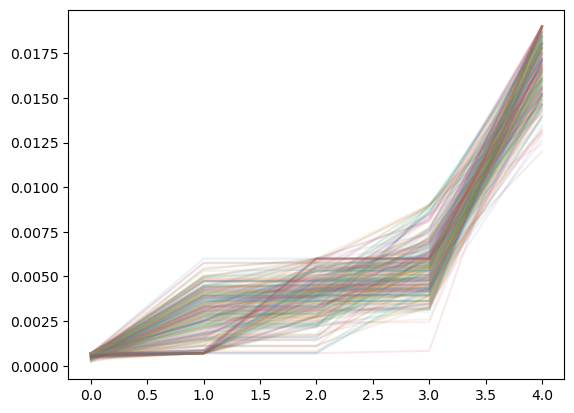

In [52]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for i in range(300):
    g = gen_attr(start_ranges_by_coeff, best_coeffs)
    ax.plot(g, alpha=0.1)
    print(g, np.diff(g), any(np.diff(g) < 0))
plt.show()